<a href="https://colab.research.google.com/github/akankshasoni22/akankshasoni22/blob/main/WalMart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT WALLMART

#Problem statement-
**analyzing the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions,to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men?**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom,norm,t
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
!gdown 1w0Ul0hrn9JzgL-UY4W-l3y1L8jXawCfp

Downloading...
From: https://drive.google.com/uc?id=1w0Ul0hrn9JzgL-UY4W-l3y1L8jXawCfp
To: /content/walmart_data.txt
100% 23.0M/23.0M [00:00<00:00, 92.2MB/s]


In [ ]:
data=pd.read_csv('walmart_data.txt')
data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365


In [ ]:
data.shape # data has 550068 rows and 10 columns

(550068, 10)

In [ ]:
data.columns
# columns -User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
#      'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
#      'Purchase


Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


Data has 10 columns and NO missing values.

1 User_id= It gives info of id of user and it is numerical.

2 Product_id=it = it gives id of product and it is object ie it is a categorical column.

3 Gender= info of gender of customer ie male or female and it is a categorical column.

4 Age - age range of customers,categorical and no missing data.

5  Occupation -int type data,give info of occupation.

6   City_Category -city is divided in categories ,it gives info of customer belong to which category of cities.its categorical.  

7   Stay_In_Current_City_Years -this column is about customer lives in its current city from how many years.its an categorical column.

 8   Marital_Status-it tells  marital status of customer ,0 is unmarried and 1 for married customer,it is int type with no missing value.

 9   Product_Category -it gives info of product belong to which category ,it is int type with no missing value.

10 Purchase -this column is basically amount of money spend to purchase product by customer.it is int type with no missing values.                  





In [ ]:
print(data.Gender.value_counts())
print(data.Age.value_counts())
print(data.Occupation.value_counts())
print(data.City_Category.value_counts())
print(data.Stay_In_Current_City_Years.value_counts())
print(data.Marital_Status.value_counts())
print(data.Product_Category.value_counts())


Gender
M    414259
F    135809
Name: count, dtype: int64
Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64
Occupation
4     72308
0     69638
7     59133
1     47426
17    40043
20    33562
12    31179
14    27309
2     26588
16    25371
6     20355
3     17650
10    12930
5     12177
15    12165
11    11586
19     8461
13     7728
18     6622
9      6291
8      1546
Name: count, dtype: int64
City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64
Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64
Marital_Status
0    324731
1    225337
Name: count, dtype: int64
Product_Category
5     150933
1     140378
8     113925
11     24287
2      23864
6      20466
3      20213
4      11753
16      9828
15      6290
13      5549
10      5125
12      3947
7       3721
18      3125
20      2550
19      1603
14      1523
17

In [ ]:
data.Product_ID=data.Product_ID.astype('category')
data.Gender=data.Gender.astype('category')
data.Age=data.Age.astype('category')
data.City_Category=data.City_Category.astype('category')
data.Stay_In_Current_City_Years=data.Stay_In_Current_City_Years.astype('category')


In [ ]:
data.info()
# object to category conversion of columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  category
 2   Gender                      550068 non-null  category
 3   Age                         550068 non-null  category
 4   Occupation                  550068 non-null  int64   
 5   City_Category               550068 non-null  category
 6   Stay_In_Current_City_Years  550068 non-null  category
 7   Marital_Status              550068 non-null  int64   
 8   Product_Category            550068 non-null  int64   
 9   Purchase                    550068 non-null  int64   
dtypes: category(5), int64(5)
memory usage: 24.3 MB


#**Correlation between columns**




In [ ]:
data_copy=data.copy()
data_copy.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
data_copy['Gender']=data_copy['Gender'].replace({'F':0,'M':1}).astype('int')
data_copy['City_Category']=data_copy['City_Category'].replace(['A','B','C'],[1,2,3]).astype('int')
data_copy['Stay_In_Current_City_Years']=data_copy['Stay_In_Current_City_Years'].replace(['1','2','3','4+'],[1,2,3,4]).astype('int')
data_copy['Age']=data_copy['Age'].replace(['0-17','18-25','26-35','36-45','46-50','51-55','55+'],[1,2,3,4,5,6,7]).astype('int')
data_copy.head(5)



/tmp/ipython-input-11-293408928.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_copy['Gender']=data_copy['Gender'].replace({'F':0,'M':1}).astype('int')
/tmp/ipython-input-11-293408928.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data_copy['Gender']=data_copy['Gender'].replace({'F':0,'M':1}).astype('int')
/tmp/ipython-input-11-293408928.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,0,1,10,1,2,0,3,8370
1,1000001,P00248942,0,1,10,1,2,0,1,15200
2,1000001,P00087842,0,1,10,1,2,0,12,1422
3,1000001,P00085442,0,1,10,1,2,0,12,1057
4,1000002,P00285442,1,7,16,3,4,0,8,7969


In [ ]:
data_copy.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  category
 2   Gender                      550068 non-null  int64   
 3   Age                         550068 non-null  int64   
 4   Occupation                  550068 non-null  int64   
 5   City_Category               550068 non-null  int64   
 6   Stay_In_Current_City_Years  550068 non-null  int64   
 7   Marital_Status              550068 non-null  int64   
 8   Product_Category            550068 non-null  int64   
 9   Purchase                    550068 non-null  int64   
dtypes: category(1), int64(9)
memory usage: 39.0 MB


In [ ]:
data_copy=data_copy.drop('Product_ID',axis=1)
data_copy.corr().round(2)

,User_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
User_ID,1.00,-0.03,0.03,-0.02,0.02,-0.03,0.02,0.00,0.00
Gender,-0.03,1.00,-0.00,0.12,-0.00,0.01,-0.01,-0.05,0.06
Age,0.03,-0.00,1.00,0.09,0.12,-0.00,0.31,0.06,0.02
Occupation,-0.02,0.12,0.09,1.00,0.03,0.03,0.02,-0.01,0.02
City_Category,0.02,-0.00,0.12,0.03,1.00,0.02,0.04,-0.01,0.06
Stay_In_Current_City_Years,-0.03,0.01,-0.00,0.03,0.02,1.00,-0.01,-0.00,0.01
Marital_Status,0.02,-0.01,0.31,0.02,0.04,-0.01,1.00,0.02,-0.00
Product_Category,0.00,-0.05,0.06,-0.01,-0.01,-0.00,0.02,1.00,-0.34
Purchase,0.00,0.06,0.02,0.02,0.06,0.01,-0.00,-0.34,1.00


<Axes: >

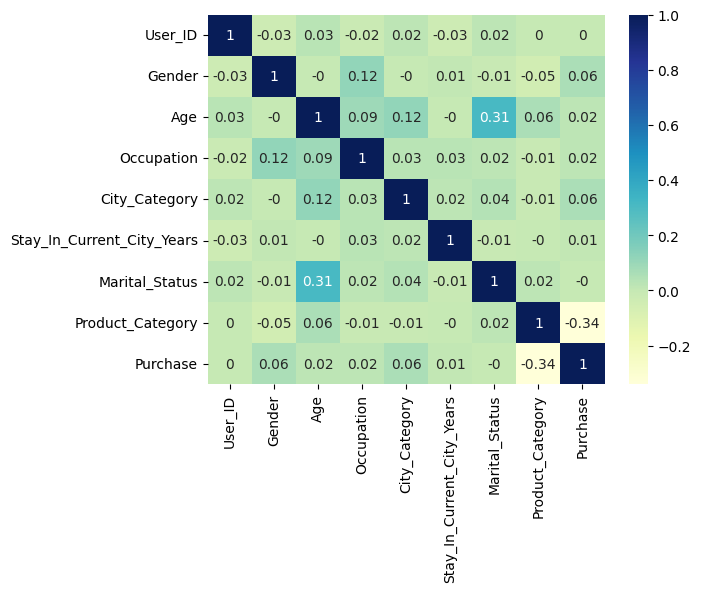

In [ ]:
sns.heatmap(data_copy.corr().round(2),cmap='YlGnBu',annot=True)

# Univariate Analysis

In [ ]:
data.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


<Axes: title={'center': 'Gender distribution'}, xlabel='Gender', ylabel='count'>

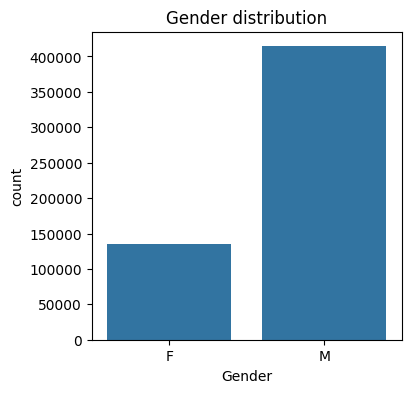

In [ ]:
plt.figure(figsize=(4,4))
plt.title('Gender distribution')
sns.countplot(x='Gender',data=data,color='g')

<Axes: xlabel='Age', ylabel='count'>

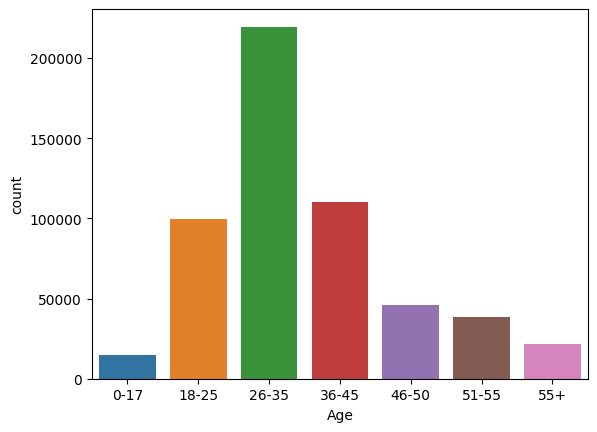

In [ ]:
sns.countplot(x='Age',data=data,hue='Age')

<Axes: title={'center': 'City distribution'}, xlabel='City_Category', ylabel='count'>

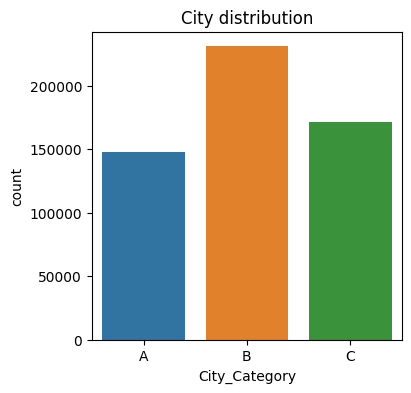

In [ ]:
plt.figure(figsize=(4,4))
plt.title('City distribution')
sns.countplot(data=data,x='City_Category',hue='City_Category')

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

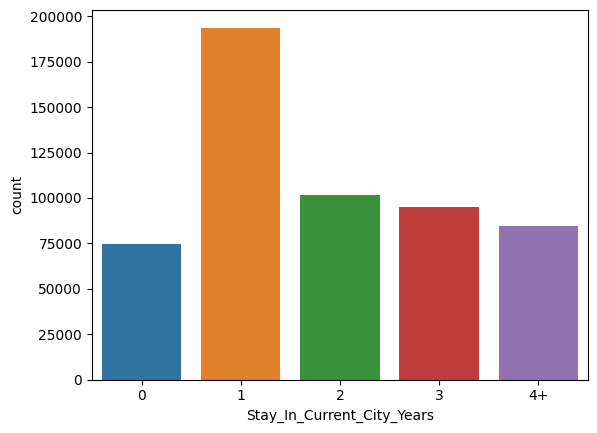

In [ ]:
sns.countplot(x='Stay_In_Current_City_Years',data=data,hue='Stay_In_Current_City_Years')

<Axes: xlabel='Purchase'>

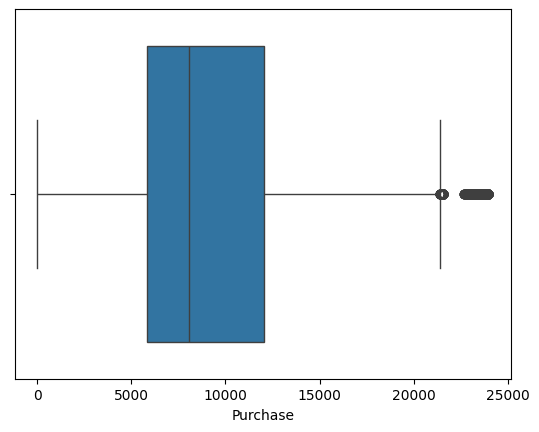

In [ ]:
sns.boxplot(x='Purchase',data=data)

<Axes: title={'center': 'Marital Status'}, xlabel='Marital_Status', ylabel='count'>

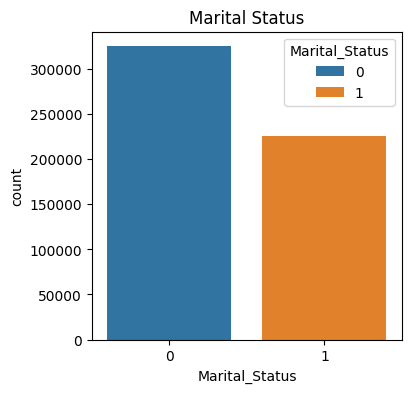

In [ ]:
data['Marital_Status']=data.Marital_Status.astype('category')
plt.figure(figsize=(4,4))
plt.title('Marital Status')
sns.countplot(x='Marital_Status',data=data,hue='Marital_Status')

<Axes: xlabel='Product_Category', ylabel='count'>

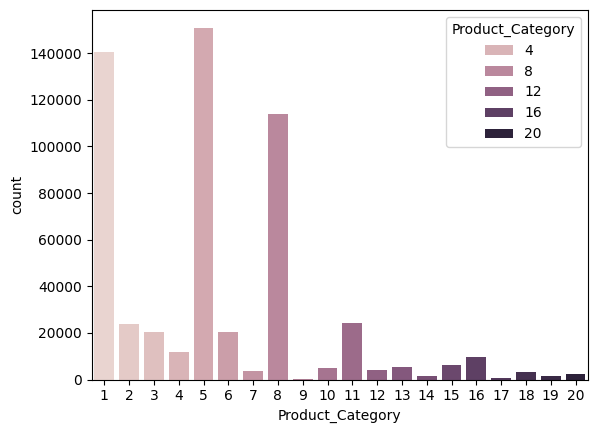

In [ ]:
sns.countplot(x='Product_Category',data=data,hue='Product_Category')

In [ ]:
print(data.Purchase.mean())

9263.968712959126


#**Bivariate Analysis**

In [ ]:
data.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


<Axes: xlabel='Marital_Status', ylabel='Purchase'>

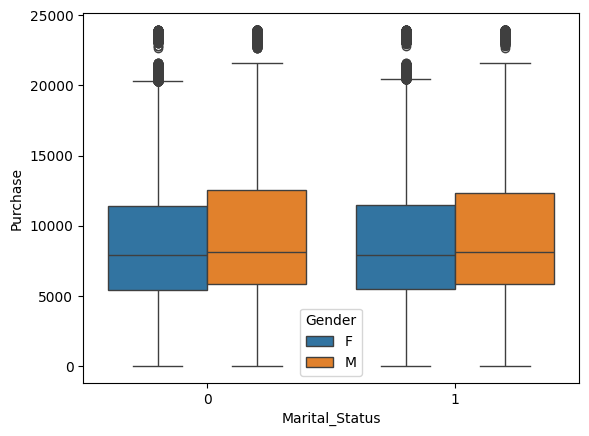

In [ ]:
sns.boxplot(x='Marital_Status',y='Purchase',data=data,hue='Gender')

<Axes: xlabel='Age', ylabel='Purchase'>

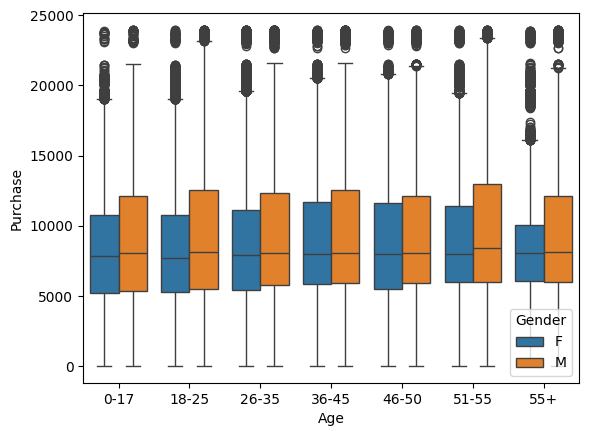

In [ ]:
sns.boxplot(data=data,x='Age',y='Purchase',hue='Gender')

<Figure size 500x500 with 0 Axes>

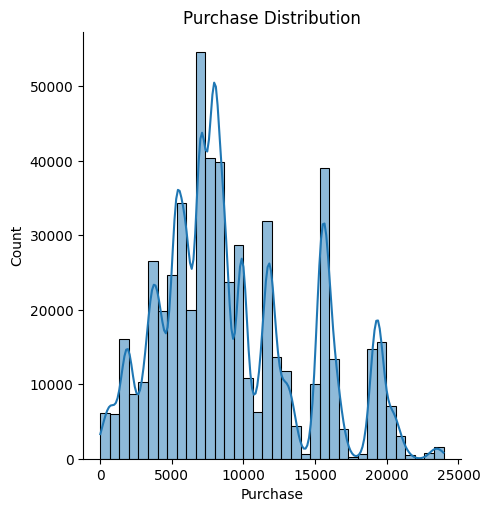

In [ ]:
# purchase distribution
plt.figure(figsize=(5,5))
sns.displot(data=data,x='Purchase',kde=True,bins=36)
plt.title('Purchase Distribution')
plt.show()

In [ ]:
bins=[-1,4500,7000,10000,15000,20000,28000]
labels=['<4.5k','4.5-7k','7-10k','10-15k','15-20k','>20k']
data['Purchase_bin']=pd.cut(data['Purchase'],bins=bins,labels=labels)
data.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase,Purchase_bin
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,7-10k
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,15-20k
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,<4.5k
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,<4.5k
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,7-10k


In [ ]:
gender_prop=pd.crosstab(data.Gender,data.Purchase_bin,margins=True,normalize='index').round(2)
gender_prop

Purchase_bin,<4.5k,4.5-7k,7-10k,10-15k,15-20k,>20k
Gender,,,,,,
F,0.17,0.21,0.33,0.13,0.14,0.02
M,0.16,0.19,0.29,0.15,0.19,0.02
All,0.16,0.20,0.30,0.14,0.18,0.02


Purchase_bin  <4.5k  4.5-7k  7-10k  10-15k  15-20k  >20k
Gender                                                  
F              0.17    0.21   0.33    0.13    0.14  0.02
M              0.16    0.19   0.29    0.15    0.19  0.02
All            0.16    0.20   0.30    0.14    0.18  0.02


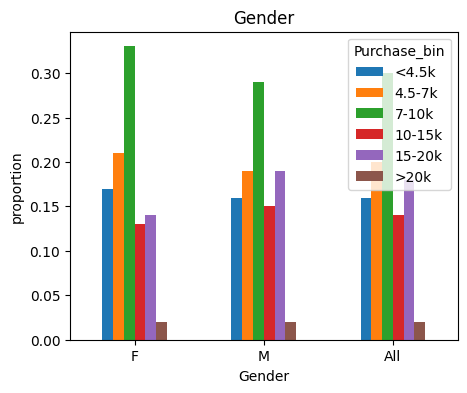

Purchase_bin  <4.5k  4.5-7k  7-10k  10-15k  15-20k  >20k
Age                                                     
0-17           0.20    0.18   0.29    0.15    0.16  0.02
18-25          0.17    0.19   0.29    0.15    0.18  0.02
26-35          0.16    0.20   0.29    0.14    0.18  0.02
36-45          0.15    0.20   0.30    0.15    0.18  0.02
46-50          0.16    0.20   0.31    0.14    0.17  0.02
51-55          0.14    0.19   0.32    0.14    0.18  0.03
55+            0.15    0.18   0.35    0.13    0.17  0.03
All            0.16    0.20   0.30    0.14    0.18  0.02


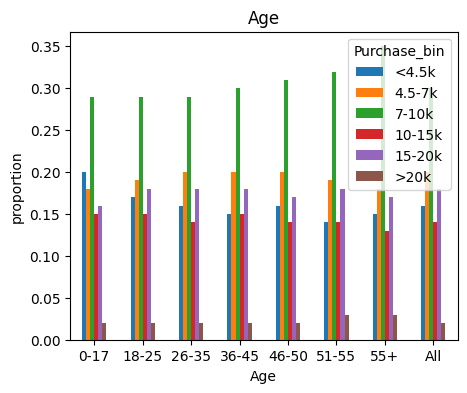

Purchase_bin    <4.5k  4.5-7k  7-10k  10-15k  15-20k  >20k
Marital_Status                                            
0                0.16     0.2    0.3    0.14    0.18  0.02
1                0.16     0.2    0.3    0.14    0.18  0.02
All              0.16     0.2    0.3    0.14    0.18  0.02


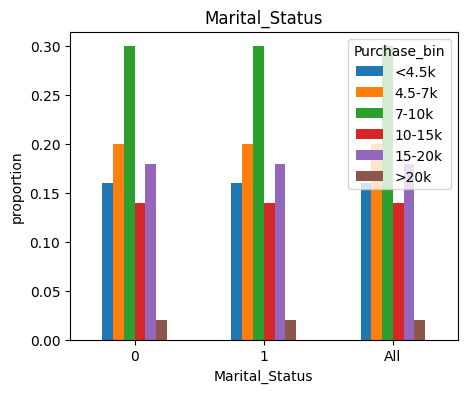

Purchase_bin   <4.5k  4.5-7k  7-10k  10-15k  15-20k  >20k
City_Category                                            
A               0.18    0.21   0.30    0.14    0.15  0.02
B               0.16    0.20   0.29    0.14    0.17  0.02
C               0.14    0.18   0.30    0.14    0.21  0.03
All             0.16    0.20   0.30    0.14    0.18  0.02


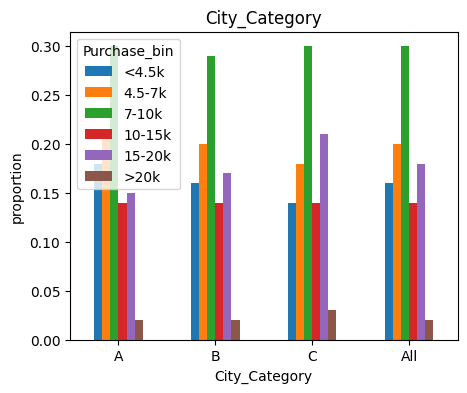

In [ ]:
cat_cols=['Gender','Age','Marital_Status','City_Category']
for i in cat_cols:
  other=pd.crosstab(data[i],data['Purchase_bin'],margins=True,normalize='index').round(2)
  print(other)
  ax=other.plot(kind='bar',title=i,figsize=(5,4))
  ax.set_xlabel(i)
  ax.set_ylabel('proportion')
  plt.xticks(rotation=0)
  plt.show()


In [ ]:
pd.crosstab(data.Gender,data.Marital_Status,margins=True)

Marital_Status,0,1,All
Gender,,,
F,78821,56988,135809
M,245910,168349,414259
All,324731,225337,550068


#**Missing values and outlier detection**

In [ ]:
data.isna().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


<Axes: xlabel='Purchase'>

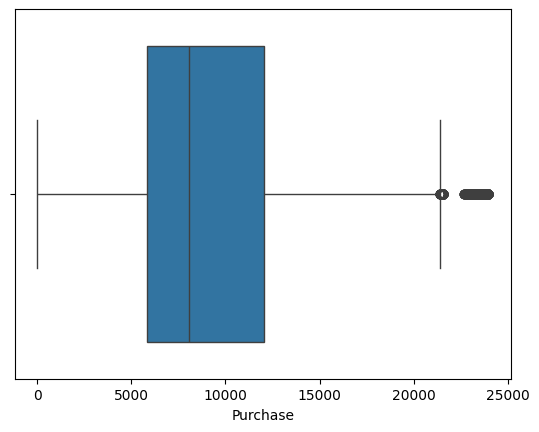

In [ ]:
#outliers in purchase column:
sns.boxplot(data=data,x='Purchase',orient='h')

In [ ]:
#purchase outliers
q1=data.Purchase.quantile(0.25)
q3=data.Purchase.quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
avg=data.Purchase.mean().round(0)
upper_bound=q3+1.5*iqr
print('Q1:',q1,'avg :',avg,'Q3:',q3,'IQR:',iqr,'Lower bound:',lower_bound,'upper :',upper_bound)

Q1: 5823.0 avg : 9264.0 Q3: 12054.0 IQR: 6231.0 Lower bound: -3523.5 upper : 21400.5


In [ ]:
outlier=data[(data.Purchase<lower_bound)|(data.Purchase>upper_bound)]
print('outlier :',len(outlier))
print('upper_limit',len(data[data.Purchase>upper_bound]))
np.round((len(outlier)/len(data.Purchase)),4)

outlier : 2677
upper_limit 2677


np.float64(0.0049)

In [ ]:
outlier['Purchase'].head(5) #has higher purchase amount can not be discarded

,Purchase
343,23603
375,23792
652,23233
736,23595
1041,23341


In [ ]:
lower_bound=data.Purchase.quantile(0.05)
upper_bound=data.Purchase.quantile(0.95)
print('lower bound:',lower_bound,'upper bound:',upper_bound)

data["Purchase"]=np.clip(data["Purchase"],lower_bound,upper_bound)

lower bound: 1984.0 upper bound: 19336.0


In [ ]:
outlier.Age.value_counts()

,count
Age,
26-35,926
36-45,604
18-25,326
51-55,310
46-50,259
55+,182
0-17,70


# **Business insights**


# Univariate analysis
1. Male customers count is significantly higher than female.

2. Age group  '26-35' , '18-25', '36-45'
 seem to purchase more as in distribution.

3. City category wise category  'B'  seem to purchase more in
univariate plot.

4. In product category product  '5' , '8'  seem to be favourate product categories for customers.

5. Purchase amount more likely to lie between 4k to 15k where average amount seem to be 9 k.

6. Some of customers buy more than 20 k amount are belong to '26 to 45'group.

7. Data has no missing values.

8. some of customers are out of normal amount of purchase ,and seem to be valuable customers.

9. Range of attributes:-
   
   1. Age range between < 17 to 55+.
   2. Purchase mostly range between 500 to 24k.
   3. Category of product devided in 20 categories.
   4. City in 3 categories.

# BIVARIATE ANALYSIS:-
   
   1. Gender proportions-
    a. male proportion divided in all categories.
    b.male are likely to purchase
    12k -22k alse.
    c. Female are more divided in 4k to 10k.

  2. Age Proportions-
     
     a. Each age group equaly likely purchase  '7k - 10 k'
     amount.

     b. But with Univariate analysis we can visual that some age groups 25 to 45 purchase more than other.

Marital_status:-
  
  a. marital status distribution shows that unmarried customer count is significantly higher than married customers.

  b. As we se proportion plot we can conclude that each coutomer falls for all purchase bin ,which seem to be uncertain.


# Distribution of variables:-

 1. Age is divided is less than 17 to 55 + , and

 ['26-35'age group has- 2,19,587 customers]

 ['36-45' age group has - 1,10,013 customers ]

 ['18-25' age group has - 99,660
 customers]

 which is 80 % of customers.

 2. Male and female customer distribution:-

  ['Male' - 4,14,259 customers ]

  ['Female' - 1,35,809 customers]

  male customers are 3 timers more than female customers.

  
3. Married and Unmarried customer distribution:-

  ['Unmarried' - 3,24,731 customers]

  ['Married' -  2,25,337 customers]

  distribution shows unmarried customers are higher than married customers.

4. Gender and marrital status distribution shows:-

  
  [Female -	unmarried 78,821	 married -56,988	]

  [Male	- unmarried 2,45,910
   married -	1,68,349]

# overview:-
 It shows that unmarried males are more in wallmart customers.

and overall unmarried customers are more in wallmart.

singles purchase more in store.

male customers are more .








     






In [ ]:
data.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase,Purchase_bin
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,7-10k
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,15-20k
2,1000001,P00087842,F,0-17,10,A,2,0,12,1984,<4.5k
3,1000001,P00085442,F,0-17,10,A,2,0,12,1984,<4.5k
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,7-10k


# Are women spending more money per transaction then men? why or why not?

In [ ]:
data.groupby('Gender')['Purchase'].mean()

/tmp/ipython-input-40-427177939.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Gender')['Purchase'].mean()


,Purchase
Gender,
F,8736.540266
M,9427.240997


In [ ]:
male=data[data['Gender']=='M']['Purchase']
female=data[data['Gender']=='F']['Purchase']
m1=male.mean()
m2=female.mean()
print('male mean:',m1,'female mean:',m2)

male mean: 9427.240996574606 female mean: 8736.540266109021


#  man spend more in per trancation than female.

In [ ]:
#Ho(Null Hypothesis):-- m1=m2(male avg spend per transaction is
# same as female)
#Ha(alternative hypo):-- m1!=m2(male hypo is not equal to female hypo)
m1

np.float64(9427.240996574606)

In [ ]:
# sample size for male is n1,sample size for female is n2
n1=male.count()
n2=female.count()
print('male count:',n1,'female count:',n2)

male count: 414259 female count: 135809


In [ ]:
t_stat,p_value=ttest_ind(male,female,alternative='greater')
print('t_stat:',t_stat,'p_value:',p_value)

t_stat: 45.574933432542736 p_value: 0.0


test result shows avg spend of male is greater than female.because pval<alpla.(here alpha is significance level which is 0.05)

In [ ]:
# que : what products diff age groups are buying?
pd.crosstab(data.Age,data.Product_Category)

Product_Category,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Age,,,,,,,,,,,,,,,,,,,,
0-17,3585,805,1200,758,4330,399,53,2258,16,111,740,125,112,39,160,229,6,27,59,90
18-25,26962,4428,4710,2463,28522,3749,481,17911,63,603,4597,439,756,230,1024,1598,41,339,275,469
26-35,58249,8928,7662,4192,61473,8485,1651,44256,154,1787,9874,1096,2096,564,2372,4118,127,1042,563,898
36-45,27648,4912,3854,2354,29377,3899,809,23296,107,1235,4953,994,1250,312,1395,1955,135,702,320,506
46-50,10474,2105,1376,990,11971,1622,327,10656,33,520,2104,520,551,149,602,879,95,351,149,227
51-55,9049,1781,924,678,9893,1450,266,9340,29,519,1458,433,483,154,508,672,107,423,134,200
55+,4411,905,487,318,5367,862,134,6208,8,350,561,340,301,75,229,377,67,241,103,160


<Axes: xlabel='Product_Category', ylabel='Count'>

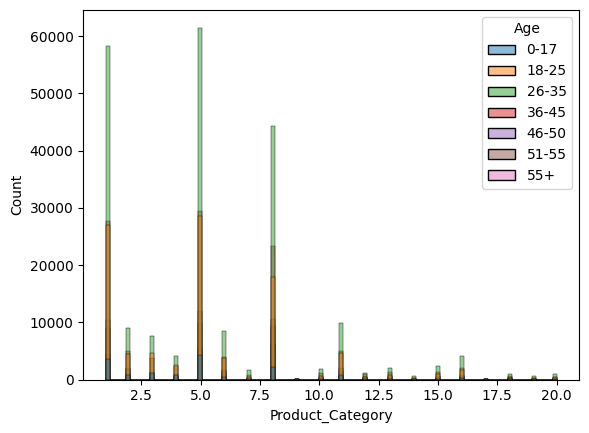

In [ ]:
sns.histplot(hue=data.Age,x=data.Product_Category)

Product category 1 ,5 ,8 are fav categories by all age groups.
  
  1. '18-25' and '26 - 35' are age groups which buy most of the these products.



<Axes: xlabel='Age', ylabel='Count'>

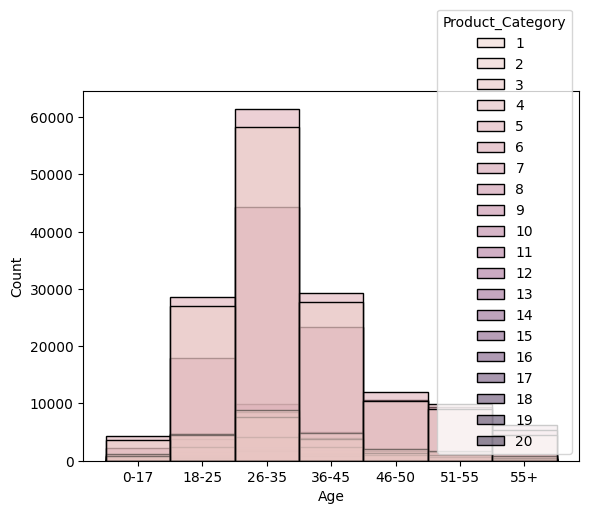

In [ ]:
sns.histplot(x='Age',hue='Product_Category',data=data)

In [ ]:
# Que:Is there a relationship between age, marital status, and the amount spent?
data.Marital_Status=data.Marital_Status.astype('category')

<Axes: xlabel='Age', ylabel='Purchase'>

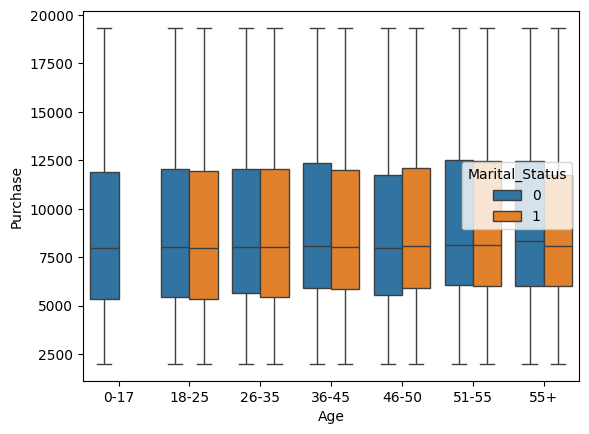

In [ ]:
sns.boxplot(x='Age',y='Purchase',data=data,hue='Marital_Status')

18 to 55 + each age group has lumsum same purchase amount pattern.that is 6k to 12k.
average purchase amount is same which is 9000.

<Axes: xlabel='Product_Category', ylabel='Count'>

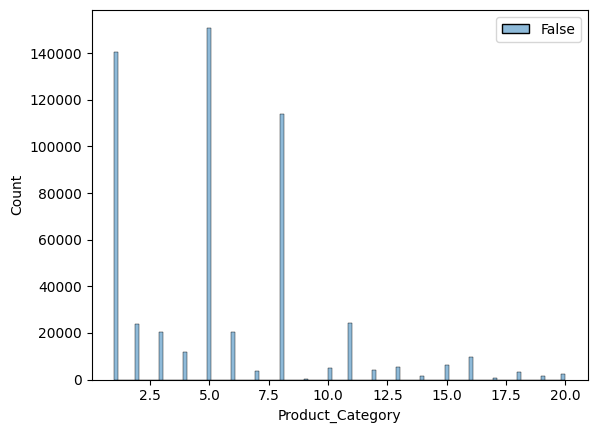

In [ ]:
# c. Are there preferred product categories for different genders?
sns.histplot(hue='Gender'=='M',data=data,x="Product_Category")

A. Product category 1 , 5 , 8 are preffered by both male and female.

B. product cat 14, 16 are prefferd by females.

C. product cat 18  , 15 are preffered by male.


<Axes: xlabel='Product_Category', ylabel='Count'>

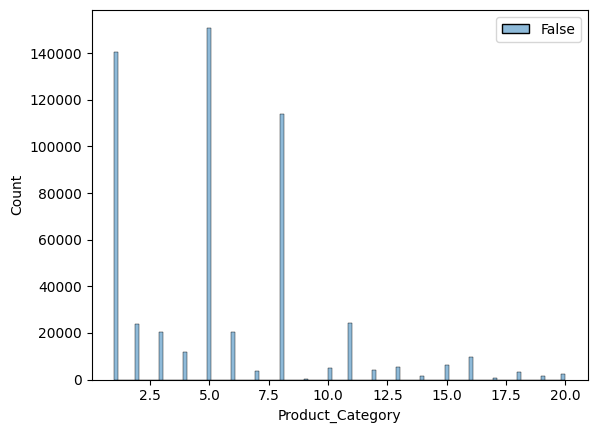

In [ ]:
sns.histplot(data=data,x='Product_Category',hue='Gender'=='F')

# Que :-- Confidence intervals and distribution of mean of expenses by male and female customers?

In [ ]:
female.head(5),male.head(5)

(0      8370
 1     15200
 2      1984
 3      1984
 14     5378
 Name: Purchase, dtype: int64,
 4     7969
 5    15227
 6    19215
 7    15854
 8    15686
 Name: Purchase, dtype: int64)

In [ ]:
#confidence interval for male:
n1=len(male)#data sample size
x1bar=male.mean()#sample mean for male
print("population mean :- ",x1bar)
s1=male.std()# sample std deviation
print("population std dev :-",s1)
se_m=male.std()/np.sqrt(n1)# sample std deviation
CL=0.95 #confidence level
CI_male=norm.interval(CL,loc=x1bar,scale=se_m)
CI_male=np.round(CI_male,0)
print('Confidence interval for male:',CI_male)

population mean :-  9427.240996574606
population std dev :- 4925.9534922859
Confidence interval for male: [9412. 9442.]


In [ ]:
#bootstraping for male samples for 300
import random
ni=300 #population mean
np.random.seed(123)
CL=0.95
sam1=np.random.choice(male,n1)
m1=sam1.mean()
print("sample mean of 300 :- ",m1)
se=sam1.std()/np.sqrt(n1)
CI_1=norm.interval(0.95,m1,se)
CI_1=np.round(CI_1,0)
print('Confidence interval for male with sample size 300:',CI_1)



sample mean of 300 :-  9431.605937348373
Confidence interval for male with sample size 300: [9417. 9447.]


In [ ]:
#bootstaping for sample size 3000
random.seed(123)
ni=3000
CL=0.95
sam=np.random.choice(male,ni)
m2=sam.mean()
se=sam.std()/np.sqrt(ni)
CI_2=norm.interval(CL,m2,se)
print('Confidence interval for male with sample size 3000:',np.round(CI_2,0))

Confidence interval for male with sample size 3000: [9343. 9696.]


In [ ]:
# bootstraping for sample size 30000
random.seed(123)
n=30000
CL=0.95
sam=np.random.choice(male,n)
m3=sam.mean()
se=sam.std()/np.sqrt(n)
CI_3=norm.interval(CL,m3,se)
print('Confidence interval for male with sample size 30000:',np.round(CI_3,0))

Confidence interval for male with sample size 30000: [9362. 9473.]


In [ ]:
("sample mean for male expenses :-",np.round((x1bar,m1,m2,m3),0))

('sample mean for male expenses :-', array([9427., 9432., 9520., 9417.]))

**Confidence interval for female**


In [ ]:
#Condidence interval for female:-
n2=len(female)#data sample size
print('size of sample : ',n2)
x2bar=female.mean()#sample mean for female
print("popolation mean :",x2bar)
se=female.std()/np.sqrt(n2)# sample error
CL=0.95
CI_female=norm.interval(CL,x2bar,se)
CI_female=np.round(CI_female,0)
print('Confidence interval for female:',CI_female)

size of sample :  135809
popolation mean : 8736.540266109021
Confidence interval for female: [8712. 8761.]


In [ ]:
#Bootstraping for sample size 300,3000,30000
np.random.seed(123)
n1=300
n2=3000
n3=30000
sam1=np.random.choice(female,n1)
sam2=np.random.choice(female,n2)
sam3=np.random.choice(female,n3)
m1=np.round(sam1.mean(),0)
m2=np.round(sam2.mean(),0)
m3=np.round(sam3.mean(),0)
print("sample mean of 300 :- ",m1)
print("sample mean of 3000 :- ",m2)
print("sample mean of 30000 :- ",m3)
CI_1=norm.interval(0.95,m1,sam1.std()/np.sqrt(n1))
CI_2=norm.interval(0.95,m2,sam2.std()/np.sqrt(n2))
CI_3=norm.interval(0.95,m3,sam3.std()/np.sqrt(n3))
CI_1=np.round(CI_1,0)
CI_2=np.round(CI_2,0)
CI_3=np.round(CI_3,0)
print('Confidence interval for female with sample size 300:',CI_1)
print('Confidence interval for female with sample size 3000:',CI_2)
print('Confidence interval for female with sample size 30000:',CI_3)

sample mean of 300 :-  8419.0
sample mean of 3000 :-  8773.0
sample mean of 30000 :-  8738.0
Confidence interval for female with sample size 300: [7902. 8936.]
Confidence interval for female with sample size 3000: [8607. 8939.]
Confidence interval for female with sample size 30000: [8686. 8790.]


In [ ]:
print("CI for female",CI_female)
print("CI for male",CI_male)

CI for female [8712. 8761.]
CI for male [9412. 9442.]


1. confidende interval of expences of male and female is not overlaping.
2. male customers are 4 lacks in sample and female customers are 1 lack.
3. confidence interval for male is 9422 to 9453,

  and for female Confidence interval is 8709 to 8760.
4. When we increase sample size sample mean reaches near to data mean and  confidence interval also reaches near to confidence interval
of original data.

5. Confidence interval of different sample size overlap.

6. sample size affect the shape of distribution of sample mean

female overall expenses mean -8734.5

sample mean of 300 :-  8406.0

sample mean of 3000 :-  8765.0

sample mean of 30000 :-  8741.0

Confidence interval for female for overall data: [8709. 8760.]

Confidence interval for female with sample size 300: [7872. 8940.]

Confidence interval for female with sample size 3000: [8593. 8937.]

Confidence interval for female with sample size 30000: [8687. 8795.]

7. Confidence interval using entire data , female data set has wider range than male

CI for female [8709. 8760.]
CI for male [9422. 9453.]

that shows :- A narrow confidence interval enables more precise population estimates. male data set giving more precise population estimate.

8. Confidence interval of male and female for entire data is not overlaping that shows- average spending behavior for male and female is diffrent,so walmart should offer diverse range of products to male and female customers.













# 5. How does Marital_Status affect the amount spent?


In [ ]:
data.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase,Purchase_bin
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,7-10k
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,15-20k
2,1000001,P00087842,F,0-17,10,A,2,0,12,1984,<4.5k
3,1000001,P00085442,F,0-17,10,A,2,0,12,1984,<4.5k
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,7-10k


In [ ]:
Unmarried=data[data['Marital_Status']==0]['Purchase']
Married=data[data['Marital_Status']==1]['Purchase']

In [ ]:
n1=len(Unmarried)
n2=len(Married)
print('Unmarried count:',n1,'Married count:',n2)

Unmarried count: 324731 Married count: 225337


In [ ]:
#confidence interval for entire data for unmarried and married customers
m1=Unmarried.mean()
m2=Married.mean()
print('Unmarried mean:',m1,'Married mean:',m2)
se1=Unmarried.std()/np.sqrt(n1)
se2=Married.std()/np.sqrt(n2)
CL=0.95
CI_UNM=norm.interval(CL,m1,se1)
CI_MAR=norm.interval(CL,m2,se2)
CI_UNM=np.round(CI_UNM,0)
CI_MAR=np.round(CI_MAR,0)
print('Confidence interval for unmarried:',CI_UNM)
print('Confidence interval for married:',CI_MAR)

Unmarried mean: 9258.820463706883 Married mean: 9253.669823420034
Confidence interval for unmarried: [9242. 9276.]
Confidence interval for married: [9234. 9274.]


# mean (avg expense)- for unmarried and married are not significanly differ from each other.

Confidence interval for married and unmarried couple are overlapping.that shows average expense of married and unmarried are same.


In [ ]:
# Bootstraping for sample size 300,3000,30000 to find sample mean and CI
np.random.seed(123)
n1=300
n2=3000
n3=30000
sam1=np.random.choice(Unmarried,n1)
sam2=np.random.choice(Unmarried,n2)
sam3=np.random.choice(Unmarried,n3)
m1=np.round(sam1.mean(),0)
m2=np.round(sam2.mean(),0)
m3=np.round(sam3.mean(),0)
print("sample mean of 300 :- ",m1)
print("sample mean of 3000 :- ",m2)
print("sample mean of 30000 :- ",m3)
CI_1=np.round(norm.interval(0.95,m1,sam1.std()/np.sqrt(n1)),0)
CI_2=np.round(norm.interval(0.95,m2,sam2.std()/np.sqrt(n2)),0)
CI_3=np.round(norm.interval(0.95,m3,sam3.std()/np.sqrt(n3)),0)
print('Confidence interval for unmarried with sample size 300:',CI_1)
print('Confidence interval for unmarried with sample size 3000:',CI_2)
print('Confidence interval for unmarried with sample size 30000:',CI_3)

sample mean of 300 :-  8857.0
sample mean of 3000 :-  9318.0
sample mean of 30000 :-  9239.0
Confidence interval for unmarried with sample size 300: [8318. 9396.]
Confidence interval for unmarried with sample size 3000: [9145. 9491.]
Confidence interval for unmarried with sample size 30000: [9184. 9294.]


In [ ]:
# Bootstraping for sample size 300,3000,30000 to find sample mean and CI
np.random.seed(123)
n1=300
n2=3000
n3=30000
sam1=np.random.choice(Married,n1)
sam2=np.random.choice(Married,n2)
sam3=np.random.choice(Married,n3)
m1=np.round(sam1.mean(),0)
m2=np.round(sam2.mean(),0)
m3=np.round(sam3.mean(),0)
print("sample mean of 300 :- ",m1)
print("sample mean of 3000 :- ",m2)
print("sample mean of 30000 :- ",m3)
CI_1=np.round(norm.interval(0.95,m1,sam1.std()/np.sqrt(n1)),0)
CI_2=np.round(norm.interval(0.95,m2,sam2.std()/np.sqrt(n2)),0)
CI_3=np.round(norm.interval(0.95,m3,sam3.std()/np.sqrt(n3)),0)
print('Confidence interval for married with sample size 300:',CI_1)
print('Confidence interval for married with sample size 3000:',CI_2)
print('Confidence interval for married with sample size 30000:',CI_3)

sample mean of 300 :-  9362.0
sample mean of 3000 :-  9435.0
sample mean of 30000 :-  9288.0
Confidence interval for married with sample size 300: [8789. 9935.]
Confidence interval for married with sample size 3000: [9258. 9612.]
Confidence interval for married with sample size 30000: [9233. 9343.]


# que 6 :- How does age affect the amount spend?

In [ ]:
data.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase,Purchase_bin
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,7-10k
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,15-20k
2,1000001,P00087842,F,0-17,10,A,2,0,12,1984,<4.5k
3,1000001,P00085442,F,0-17,10,A,2,0,12,1984,<4.5k
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,7-10k


In [ ]:
#confidence interval for each age catego
student=data[data["Age"]=='0-17']['Purchase']
clg=data[data["Age"]=='18-25']['Purchase']
adult=data[data["Age"]=='26-35']['Purchase']
mid_age=data[data["Age"]=='36-45']['Purchase']
senior=data[(data["Age"]=='46-50')|(data["Age"]=='51-55')|(data['Age']=='55+')]['Purchase']



In [ ]:
data.Age.value_counts()

,count
Age,
26-35,219587
36-45,110013
18-25,99660
46-50,45701
51-55,38501
55+,21504
0-17,15102


In [ ]:
n1=student.count()
n2=clg.count()
n3=adult.count()
n4=mid_age.count()
n5=senior.count()
print('student count:',n1,'clg going count:',n2,' adult count:',n3,'mid age count:',n4,'senior count:',n5)

student count: 15102 clg going count: 99660  adult count: 219587 mid age count: 110013 senior count: 105706


In [ ]:
m1=np.round(np.mean(student),0)
m2=np.round(np.mean(clg),0)
m3=np.round(np.mean(adult),0)
m4=np.round(np.mean(mid_age),0)
m5=np.round(np.mean(senior),0)
print('student mean:',m1,'clg going mean:',m2,' adult mean:',m3,'mid age mean:',m4,'senior mean:',m5)

student mean: 8941.0 clg going mean: 9169.0  adult mean: 9244.0 mid age mean: 9323.0 senior mean: 9343.0


In [ ]:
#confidence interval for different age groups:
CI_1=np.round(norm.interval(0.95,m1,student.std()/np.sqrt(n1)))
CI_2=np.round(norm.interval(0.95,m2,clg.std()/np.sqrt(n2)))
CI_3=np.round(norm.interval(0.95,m3,adult.std()/np.sqrt(n3)))
CI_4=np.round(norm.interval(0.95,m4,mid_age.std()/np.sqrt(n4)))
CI_5=np.round(norm.interval(0.95,m5,senior.std()/np.sqrt(n5)))

In [ ]:
print('Confidence interval for student:',CI_1)
print('Confidence interval for clg going:',CI_2)
print('Confidence interval for adult:',CI_3)
print('Confidence interval for mid age:',CI_4)
print('Confidence interval for senior:',CI_5)

Confidence interval for student: [8862. 9020.]
Confidence interval for clg going: [9139. 9199.]
Confidence interval for adult: [9224. 9264.]
Confidence interval for mid age: [9294. 9352.]
Confidence interval for senior: [9314. 9372.]


#Final Insights:-
# Univariate analysis
1. Male customers count is significantly higher than female.

2. Age group  '26-35' , '18-25', '36-45'
 seem to purchase more as in distribution.

3. City category wise category  'B'  seem to purchase more in
univariate plot.

4. In product category product  '5' , '8'  seem to be favourate product categories for customers.

5. Purchase amount more likely to lie between 4k to 15k where average amount seem to be 9 k.

6. Some of customers buy more than 20 k amount are belong to '26 to 45'group.

7. Data has no missing values.

8. some of customers are out of normal amount of purchase ,and seem to be valuable customers.

9. Range of attributes:-
   
   1. Age range between < 17 to 55+.
   2. Purchase mostly range between 500 to 24k.
   3. Category of product devided in 20 categories.
   4. City in 3 categories.

# BIVARIATE ANALYSIS:-
   
   1. Gender proportions-
    a. male proportion divided in all categories.
    b.male are likely to purchase
    12k -22k alse.
    c. Female are more divided in 4k to 10k.

  2. Age Proportions-
     
     a. Each age group equaly likely purchase  '7k - 10 k'
     amount.

     b. But with Univariate analysis we can visual that some age groups 25 to 45 purchase more than other.

Marital_status:-
  
  a. marital status distribution shows that unmarried customer count is significantly higher than married customers.

  b. As we se proportion plot we can conclude that each coutomer falls for all purchase bin ,which seem to be uncertain.


# Distribution of variables:-

 1. Age is divided is less than 17 to 55 + , and

 ['26-35'age group has- 2,19,587 customers]

 ['36-45' age group has - 1,10,013 customers ]

 ['18-25' age group has - 99,660
 customers]

 which is 80 % of customers.

 2. Male and female customer distribution:-

  ['Male' - 4,14,259 customers ]

  ['Female' - 1,35,809 customers]

  male customers are 3 timers more than female customers.

  
3. Married and Unmarried customer distribution:-

  ['Unmarried' - 3,24,731 customers]

  ['Married' -  2,25,337 customers]

  distribution shows unmarried customers are higher than married customers.

4. Gender and marrital status distribution shows:-

  
  [Female -	unmarried 78,821	 married -56,988	]

  [Male	- unmarried 2,45,910
   married -	1,68,349]

# overview:-
 It shows that unmarried males are more in wallmart customers.

and overall unmarried customers are more in wallmart.

singles purchase more in store.

male customers are more .

# Confidence interval and average expenses:

1. confidence interval of expences of male and female is not overlaping.so walmart can offer much diverse products between male and female customer.

2. It is clearly shows that female expences per transaction is less than male.

#confidence interval of married and unmarried:

1.its overlapping between married and unmarried customers.

2.mean distribution is not far from each other.

# Confidence intevals between ages:-
1. mean of age groups are not far from each other.

2. less than 17 years age group has less mean and confidence interval is wider than other.

3. student mean: 8941.0

clg going mean: 9169.0  

adult mean: 9244.0

mid age mean: 9323.0

senior mean: 9343.0

4. confidence interval for each age group are precise and not overlaping,that shows that walmart can offer different products to diffent age groups.

5.Confidence interval for student: [8862. 9020.]

Confidence interval for clg going: [9139. 9199.]

Confidence interval for adult: [9224. 9264.]

Confidence interval for mid age: [9294. 9352.]

Confidence interval for senior:
[9314. 9372.]











     






# Recommendadions:-

1. walmart can diverce range of products for male and female.

2. unmarried customers are higher than married, so married customer should get some offers in product categories which will atract them.

3. male customers are higher than female,female should get some discount coupons and offers which will increase female customers also.

4. Number of male customers are high in walmart,special discount on countinue purchase and on high
expense should provide to male customers.

5. less than 17 age group is less in customer data ,walmart should give special offer for teanage and kids section.

6. 50 years and avobe age group shows less participation on purchase in mart,walmart should offer special discount and coupons for senior citizen to atract them.

7. Male and female expence intervals are diffrent so walmart should offer diverce products and discounts to both gender.